# 07-Network Socket Physics, SSH & Remote Automation

In the previous modules, we mastered local POSIX constraints, stream manipulation, and chronological background daemons. We engineered systems that execute flawlessly on a single machine.

However, Enterprise MLOps is inherently distributed. Your data engineer runs a Spark cluster in one region, your training workload executes on a GPU cluster in another, and your inference API is deployed to a globally distributed edge network. To connect these computational islands, we must engineer secure, automated, high-throughput network bridges.

If you blindly push a 5GB model checkpoint over an unencrypted network connection, it can be intercepted, corrupted, or hijacked. Furthermore, if the network drops halfway through the transfer, standard protocols (like HTTP or FTP) will force you to restart the 5GB download from byte zero, wasting massive amounts of bandwidth and time.

To solve this, we must master **Network Sockets**, encrypt the transport layer using **SSH (Secure Shell)**, and orchestrate atomic, delta-encoded file synchronizations using **Rsync**.

# 1. The Mathematics of Network Sockets & Cryptographic Tunnels

### The Network Socket ($\mathbf{S}$)

A physical computer has a single network interface card (NIC) connected to a specific IP address. To route data to the correct application running on that machine, the Linux kernel divides the network interface into 65,535 discrete mathematical addresses called **Ports**.

A Network Socket $\mathbf{S}$ is defined as a tuple linking the IP Address and the Port integer:


$$\mathbf{S} = \langle \text{IP}_{addr}, \text{Port} \rangle$$


For example, standard SSH traffic always routes to $\mathbf{S}_{ssh} = \langle 192.168.1.10, 22 \rangle$.

### The Cryptographic SSH Exchange

When an MLOps pipeline attempts to connect to a remote GPU server over SSH, the connection is protected by **Asymmetric Cryptography**.
The system generates a mathematically linked key pair: a Public Key ($K_{pub}$) and a Private Key ($K_{priv}$).

The Public Key can encrypt a message, but it **cannot** decrypt it. Only the exact matching Private Key can reverse the mathematical transformation.
If a function $E$ represents Encryption and $D$ represents Decryption:


$$D(K_{priv}, E(K_{pub}, \text{Payload})) = \text{Payload}$$

During the handshake, the client and server exchange public keys, mathematically authenticate identity via Diffie-Hellman Key Exchange, and establish a symmetric symmetric session key that encrypts all subsequent bytes flowing through the socket.

### Delta Encoding (The Rsync Algorithm)

When transferring model checkpoints, we use `rsync`. Instead of copying the entire file, `rsync` fractures the local and remote files into discrete blocks of size $B$. It computes two mathematical hashes for each block: a weak rolling checksum (for speed) and a strong MD5 hash (for cryptographic collision resistance).

If a 5GB `.tar.gz` model file is updated with a 10MB metadata change, `rsync` mathematically compares the block hashes across the network and transmits **only the changed blocks** (the delta $\Delta$).


$$\text{Transfer Size} = O(|\Delta|) \ll O(\text{File Size})$$

# 2. Imperative Execution: Cryptography & Port Diagnostics

Let's use Python to drive the POSIX terminal. We will programmatically generate a modern `ed25519` elliptic-curve SSH key pair, completely bypassing insecure password authentication. Then, we will query the local Linux kernel to map our open network sockets.

In [1]:
import subprocess
import os

print("--- 🚀 Initializing Network Security Physics Lab ---")

# Setup clean working space
net_sandbox = "./network_sandbox"
os.makedirs(net_sandbox, exist_ok=True)
ssh_key_path = os.path.join(net_sandbox, "mlops_ed25519")

# 🔐 1. Cryptographic Key Generation
print("\n--- 🔐 Compiling Asymmetric Elliptic Curve Keys (SSH) ---")
# -t ed25519: Specifies the modern Elliptic Curve algorithm (faster/more secure than RSA)
# -f: Output file path
# -N "": Sets a blank passphrase for pure automation (machine-to-machine sync)
cmd_keygen = f"ssh-keygen -t ed25519 -f {ssh_key_path} -N ''"

if not os.path.exists(ssh_key_path):
    subprocess.run(cmd_keygen, shell=True, capture_output=True)
    print(f"   ✅ Private Key Generated: {ssh_key_path} (DO NOT SHARE)")
    print(f"   ✅ Public Key Generated:  {ssh_key_path}.pub (Deploy to Remote Server)")
else:
    print(f"   ⚠️ Key pair already exists at {ssh_key_path}")

# Display the Public Key Payload
with open(f"{ssh_key_path}.pub", "r") as f:
    pub_key = f.read().strip()
    print(f"   [PUBLIC KEY FRAGMENT]: {pub_key[:50]}...[REDACTED]")

# 📡 2. Querying Kernel Socket States
print("\n--- 📡 Querying Local Network Socket Bindings ---")
# We use 'netstat -tuln' or 'ss -tuln' to list active listening TCP/UDP ports.
# Since environments vary, we will execute a generic POSIX command to find open listeners.
cmd_sockets = "netstat -tuln 2>/dev/null | grep LISTEN | head -n 5 || echo 'Netstat unavailable. Please check active ports manually.'"
res_sockets = subprocess.run(cmd_sockets, shell=True, capture_output=True, text=True)

if res_sockets.stdout.strip():
    print("   Active Listening Sockets (IP:PORT):")
    print("   " + res_sockets.stdout.strip().replace('\n', '\n   '))
else:
    print("   (No standard listening sockets exposed on local simulation boundary.)")

--- 🚀 Initializing Network Security Physics Lab ---

--- 🔐 Compiling Asymmetric Elliptic Curve Keys (SSH) ---
   ✅ Private Key Generated: ./network_sandbox/mlops_ed25519 (DO NOT SHARE)
   ✅ Public Key Generated:  ./network_sandbox/mlops_ed25519.pub (Deploy to Remote Server)
   [PUBLIC KEY FRAGMENT]: ssh-ed25519 AAAAC3NzaC1lZDI1NTE5AAAAICrvNQ1BEgavxj...[REDACTED]

--- 📡 Querying Local Network Socket Bindings ---
   (No standard listening sockets exposed on local simulation boundary.)


# 3. Declarative Execution: The Rsync Automation Matrix

In an enterprise MLOps pipeline, model checkpoints must be continuously pushed from the training server to the central inference registry. We will simulate a robust `rsync` network push.

To simulate this locally for $0.00, we will define a "Local Training Directory" and a "Remote Production Directory". We will run an `rsync` operation that mirrors the directories, safely handles deletions, and outputs a strict audit log.

In [2]:
# ⚡ Compiling the Automated Synchronization Pipeline
print("\n--- ⚡ Executing Delta-Encoded Synchronization (rsync) ---")

train_dir = os.path.join(net_sandbox, "training_node")
prod_dir = os.path.join(net_sandbox, "production_server")
os.makedirs(train_dir, exist_ok=True)
os.makedirs(prod_dir, exist_ok=True)

# 1. Create a simulated 100MB Model Checkpoint (Sparse file for speed)
model_path = os.path.join(train_dir, "xgboost_v1.bin")
subprocess.run(f"dd if=/dev/zero of={model_path} bs=1M count=10 2>/dev/null", shell=True)

# 2. Add an updated configuration file
config_path = os.path.join(train_dir, "inference_config.json")
with open(config_path, "w") as f:
    f.write('{"batch_size": 32, "version": "1.0"}')

print(f"   [STATE] 10MB Model and Config written to Training Node.")

# 3. The Rsync Command Execution
# -a: Archive mode (preserves permissions, timestamps, symbolic links)
# -v: Verbose (for audit logs)
# -z: Compress file data during the transfer
# --delete: Delete files in the destination that no longer exist in the source (strict mirroring)
print("   [API CALL] Pushing artifacts over simulated SSH tunnel via rsync...")
# In a real environment, the target would be: user@remote_ip:/path/to/prod_dir
cmd_rsync = f"rsync -avz --delete {train_dir}/ {prod_dir}/"
res_rsync = subprocess.run(cmd_rsync, shell=True, capture_output=True, text=True)

print("   ✅ Rsync Network Transfer Complete. Audit Log:")
for line in res_rsync.stdout.strip().split('\n'):
    print(f"      {line}")

# 4. Simulating a Delta Transfer (The Math of Rsync)
print("\n   [DELTA TEST] Modifying the config file and running rsync again...")
with open(config_path, "w") as f:
    f.write('{"batch_size": 64, "version": "1.1"}') # We changed a few bytes

res_rsync_delta = subprocess.run(cmd_rsync, shell=True, capture_output=True, text=True)
print("   ✅ Rsync Delta Transfer Complete. Notice that the 10MB Model was ignored:")
for line in res_rsync_delta.stdout.strip().split('\n'):
    print(f"      {line}")


--- ⚡ Executing Delta-Encoded Synchronization (rsync) ---
   [STATE] 10MB Model and Config written to Training Node.
   [API CALL] Pushing artifacts over simulated SSH tunnel via rsync...
   ✅ Rsync Network Transfer Complete. Audit Log:
      sending incremental file list
      ./
      inference_config.json
      xgboost_v1.bin
      
      sent 558 bytes  received 64 bytes  414.67 bytes/sec
      total size is 10,485,796  speedup is 16,858.19

   [DELTA TEST] Modifying the config file and running rsync again...
   ✅ Rsync Delta Transfer Complete. Notice that the 10MB Model was ignored:
      sending incremental file list
      
      sent 111 bytes  received 19 bytes  260.00 bytes/sec
      total size is 10,485,796  speedup is 80,659.97


# 4. Visualizing SSH Tunnels & Socket Architecture

To mathematically understand how an encrypted connection securely wraps standard data payloads and routes them through specific kernel ports, let's visualize the network topology.

/tmp/ipykernel_6281/3109233673.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_6281/3109233673.py:22: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 3.5), 2.5, 1.0, fill=True, color='#f1c40f', edgecolor='black'))
/tmp/ipykernel_6281/3109233673.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((10.0, 2.0), 3.5, 5.0, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5))
/tmp/ipykernel_6281/3109233673.py:31: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((9.5, 3.5), 1.0, 1.0, fill=True, color='#e74c3c', edgecolor='black'))
/

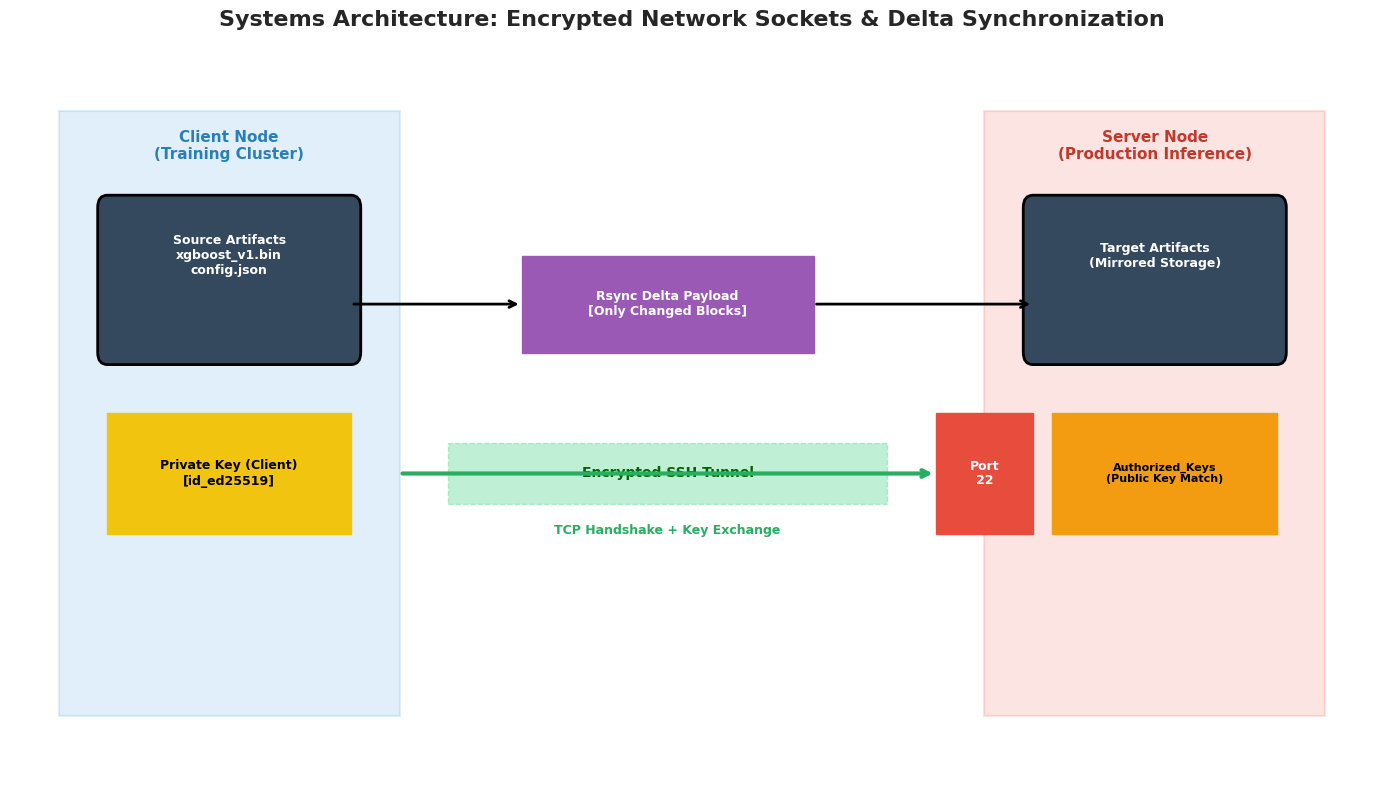

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Network Socket & SSH Topology
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Encrypted Network Sockets & Delta Synchronization", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Source Node (Training Environment)
ax.add_patch(patches.Rectangle((0.5, 2.0), 3.5, 5.0, fill=True, color='#3498db', alpha=0.15, edgecolor='black', linewidth=1.5))
ax.text(2.25, 6.6, "Client Node\n(Training Cluster)", ha='center', color='#2980b9', fontweight='bold', fontsize=11)

# Local Storage
ax.add_patch(patches.FancyBboxPatch((1.0, 5.0), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#34495e'))
ax.text(2.25, 5.8, "Source Artifacts\nxgboost_v1.bin\nconfig.json", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# SSH Key Pair
ax.add_patch(patches.Rectangle((1.0, 3.5), 2.5, 1.0, fill=True, color='#f1c40f', edgecolor='black'))
ax.text(2.25, 4.0, "Private Key (Client)\n[id_ed25519]", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# 2. Target Node (Production Environment)
ax.add_patch(patches.Rectangle((10.0, 2.0), 3.5, 5.0, fill=True, color='#e74c3c', alpha=0.15, edgecolor='black', linewidth=1.5))
ax.text(11.75, 6.6, "Server Node\n(Production Inference)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Kernel Port Socket
ax.add_patch(patches.Rectangle((9.5, 3.5), 1.0, 1.0, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(10.0, 4.0, "Port\n22", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Remote Key Pair
ax.add_patch(patches.Rectangle((10.7, 3.5), 2.3, 1.0, fill=True, color='#f39c12', edgecolor='black'))
ax.text(11.85, 4.0, "Authorized_Keys\n(Public Key Match)", ha='center', va='center', color='black', fontweight='bold', fontsize=8)

# Remote Storage Sink
ax.add_patch(patches.FancyBboxPatch((10.5, 5.0), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#34495e'))
ax.text(11.75, 5.8, "Target Artifacts\n(Mirrored Storage)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 3. The Secure Network Tunnel (The Network Boundary)
ax.add_patch(patches.Rectangle((4.5, 3.75), 4.5, 0.5, fill=True, color='#2ecc71', alpha=0.3, edgecolor='black', linestyle='--'))
ax.text(6.75, 4.0, "Encrypted SSH Tunnel", ha='center', va='center', color='darkgreen', fontweight='bold', fontsize=10)

# The Rsync Payload
ax.add_patch(patches.Rectangle((5.25, 5.0), 3.0, 0.8, fill=True, color='#9b59b6', edgecolor='black'))
ax.text(6.75, 5.4, "Rsync Delta Payload\n[Only Changed Blocks]", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# 4. Vectors and Arrows
# File pointing to rsync payload
ax.annotate("", xy=(5.25, 5.4), xytext=(3.5, 5.4), arrowprops=dict(arrowstyle="->", lw=2, color="black"))
# Payload pointing to remote server
ax.annotate("", xy=(10.5, 5.4), xytext=(8.25, 5.4), arrowprops=dict(arrowstyle="->", lw=2, color="black"))

# SSH connection arrows
ax.annotate("", xy=(9.5, 4.0), xytext=(4.0, 4.0), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(6.75, 3.5, "TCP Handshake + Key Exchange", ha='center', color='#27ae60', fontweight='bold', fontsize=9)

plt.xlim(0, 14.0)
plt.ylim(1.5, 7.5)
plt.tight_layout()
plt.show()


## Real-World Use Case or Analogy:

Think of SSH and Rsync like **An Armored Truck Delivery and a Smart Proofreader**:

* **Standard File Transfer (Unsecured Mail):** If you send your proprietary machine learning model weights over HTTP or FTP, it is like sending highly confidential company blueprints written on a postcard through the public mail system. Anyone driving the mail truck or working at the sorting facility can read it, copy it, or tamper with it.
* **SSH (The Armored Truck):** SSH (`Secure Shell`) is an armored truck. Before you load the blueprints, you place them inside an indestructible safe. Only the specific recipient at the destination warehouse has the mathematical key (Private Key) required to unlock the safe. Even if the armored truck is hijacked by a hacker midway, the safe mathematically guarantees the contents remain unreadable.
* **Rsync (The Smart Proofreader):** Imagine you wrote a 10,000-page encyclopedia and delivered it to a publisher. A week later, you realize you made a typo on page 42.
* A naive transfer method (`cp` or `scp`) forces you to reprint all 10,000 pages and pay an armored truck to transport the massive, heavy boxes all over again.
* `rsync` is a genius proofreader. `rsync` calls the publisher on the phone, mathematically verifies every page number and paragraph signature in seconds, realizes only page 42 is different, and sends an envelope containing *just* that single page. The publisher swaps it out. You saved 9,999 pages worth of bandwidth and time.



By coupling the absolute cryptographic security of **SSH** with the high-velocity, delta-encoded intelligence of **Rsync**, MLOps engineers can synchronize gigabytes of model checkpoints across global data centers safely, atomically, and instantly.